In [1]:
from EarthquakeSignal import config, EarthquakeBatchProcessor
from LadrunoGraphStyle import set_default_plot_params
set_default_plot_params()

In [2]:
# pip list

### Set config manual 

In [3]:
config = {
    'file_extension': '.txt',
    'unit_factor': 1,
    
    'apply_baseline_correction': True,
    'apply_arias_analysis': True,
    'apply_fourier_analysis': True,
    '_compute_newmark_spectra': True,
    'compute_rotd': True,
    'print_summary': True,
    
    'plot_signals': True,
    'plot_corrected_signals': True,
    'plot_arias_signals': True,
    'plot_fourier_signals': True,  
    'plot_newmark_spectra': True,
    'plot_rotd': True,
    
    'writer': True, 
}


In [4]:
registers_path = r'data/Selected'


In [5]:
processor = EarthquakeBatchProcessor(registers_path, config ,  n_jobs=4) 
earthquake = processor.process_all()


Processing earthquakes: 100%|██████████| 12/12 [00:42<00:00,  3.54s/it]


### For each earthquake

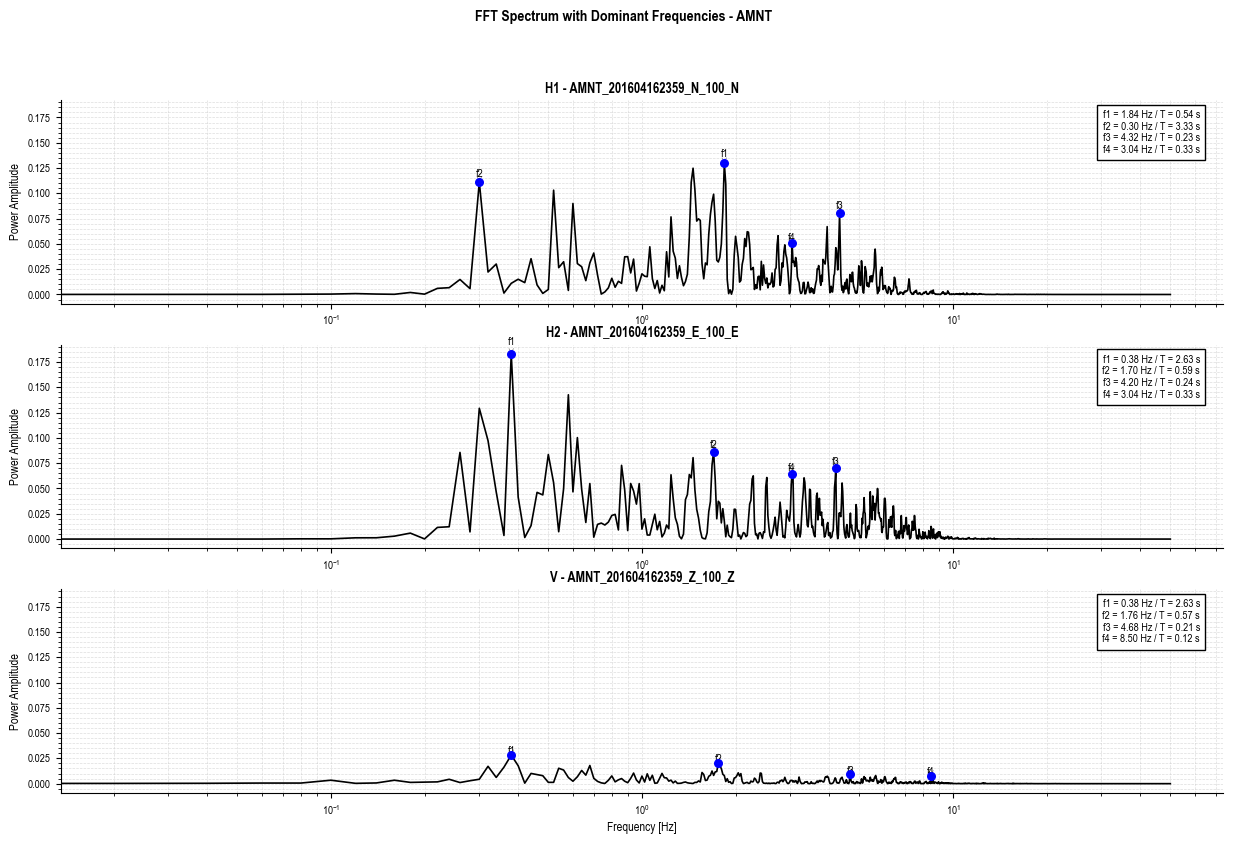

In [6]:
earthquake['AMNT'].plot_fourier_signals()

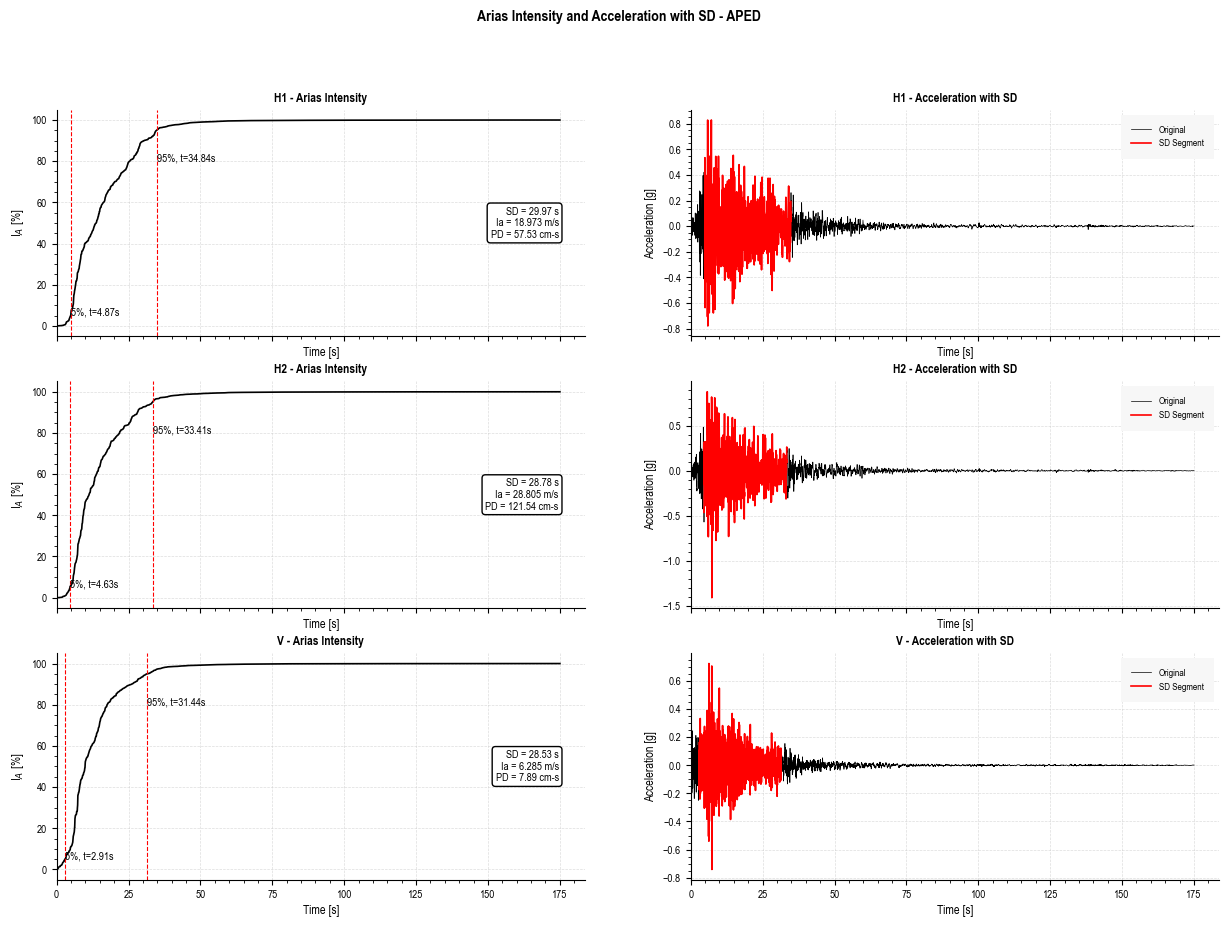

In [ ]:
# earthquake['APED'].print_summary()
# earthquake['APED'].plot_original_signals()
# earthquake['APED'].plot_corrected_signals()
# earthquake['APED'].plot_arias_signals()
# earthquake['APED'].plot_fourier_signals()
# earthquake['APED'].plot_newmark_spectra()
# earthquake['APED'].plot_rotd()


In [8]:
record = earthquake['APED']


print("🔹 Arias Intensity")
print(f"Significant Duration Start  : {record.arias['H1']['t_start']:.3f} s")
print(f"Significant Duration End    : {record.arias['H1']['t_end']:.3f} s")
print(f"Total Arias Intensity       : {record.arias['H1']['IA_total']:.5f} m/s")
print(f"Destructive Potential Index : {record.arias['H1']['pot_dest']:.5f}")


print("\n🔹 Fourier Analysis")
print("Dominant Periods (s):", record.fourier['H1']['dominant_periods'])

🔹 Arias Intensity
Significant Duration Start  : 4.870 s
Significant Duration End    : 34.840 s
Total Arias Intensity       : 18.97275 m/s
Destructive Potential Index : 0.57534

🔹 Fourier Analysis
Dominant Periods (s): [0.48888268 0.2551312  0.15640751 0.13299392]


## Keys and Methods

In [9]:

first_key = next(iter(earthquake))
eq = earthquake[first_key]

print("Keys:")
for key in vars(eq):
    print(f"  - {key}")

print("\nMethods:")
import inspect
methods = [name for name, obj in inspect.getmembers(eq, inspect.ismethod) if not name.startswith('_')]
for m in methods:
    print(f"  - {m}()")

Keys:
  - filepath
  - config
  - name
  - dt
  - signals
  - component_names
  - corrected_acc
  - corrected_vel
  - corrected_disp
  - arias
  - newmark_spectra
  - rotd
  - fourier
  - summary_tool
  - plotter_tool
  - comparison_tool
  - arias_plotter
  - fourier_plotter
  - newmark_plotter
  - rotd_plotter
  - exporter
  - signals_raw

Methods:
  - export()
  - load_and_process()
  - plot_arias_signals()
  - plot_corrected_signals()
  - plot_fourier_signals()
  - plot_newmark_spectra()
  - plot_original_signals()
  - plot_rotd()
  - print_summary()


### All spectra

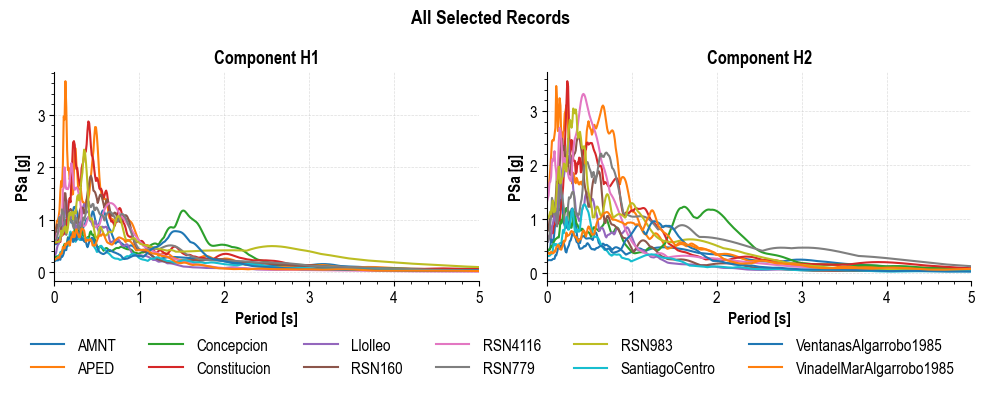

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import os

# --- Calcular ruta correcta ---
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
output_dir = os.path.join(project_root, 'outputs')
os.makedirs(output_dir, exist_ok=True)

# Puedes cambiar esta ruta si quieres guardar en otro lugar
svg_path = r'C:\Users\ppala\OneDrive\01. Brain\10. Ph.D U ANDES\07. Publicaciones\01. AmplificacionMuros\02. Modelos Shell\04. Model10stories\SelectedSeismic'

# --- Graficar espectros ---
fig=plt.figure(figsize=(10, 4))

# Subplot para H1
plt.subplot(1, 2, 1)
for rsn, eq in earthquake.items():
    try:
        T_H1 = eq.newmark_spectra['H1']['T']
        PSa_H1 = eq.newmark_spectra['H1']['PSa']
        plt.plot(T_H1, PSa_H1, linewidth=1.5, label=f"{rsn}")
    except KeyError:
        print(f"Warning: {rsn} missing H1 spectrum")

plt.title("Component H1", fontweight='bold', fontsize=13)
plt.xlabel("Period [s]", fontweight='bold', fontsize=12)
plt.ylabel("PSa [g]", fontweight='bold', fontsize=12)
plt.grid(True)
plt.xlim(left=0, right=5)
plt.tick_params(axis='both', labelsize=12)
# plt.legend(loc='upper right', ncol=2, fontsize=12)

# Subplot para H2
plt.subplot(1, 2, 2)
for rsn, eq in earthquake.items():
    try:
        T_H2 = eq.newmark_spectra['H2']['T']
        PSa_H2 = eq.newmark_spectra['H2']['PSa']
        plt.plot(T_H2, PSa_H2, linewidth=1.5, label=f"{rsn}")
    except KeyError:
        print(f"Warning: {rsn} missing H2 spectrum")

plt.title("Component H2", fontweight='bold', fontsize=13)
plt.xlabel("Period [s]", fontweight='bold', fontsize=12)
plt.ylabel("PSa [g]", fontweight='bold', fontsize=12)
plt.grid(True)
plt.xlim(left=0, right=5)
plt.tick_params(axis='both', labelsize=12)
# plt.legend(loc='upper right', ncol=2, fontsize=10)

plt.suptitle("All Selected Records", fontsize=14, fontweight='bold')

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=12, frameon=False)
plt.tight_layout(rect=[0, 0.15, 1, 1])

# --- Guardar figuras ---
plt.savefig(os.path.join(svg_path, 'seismic_selected.pdf'), format='pdf', bbox_inches='tight')
plt.savefig(os.path.join(svg_path, 'seismic_selected.svg'), format='svg', bbox_inches='tight')
plt.show()


### Rotd100

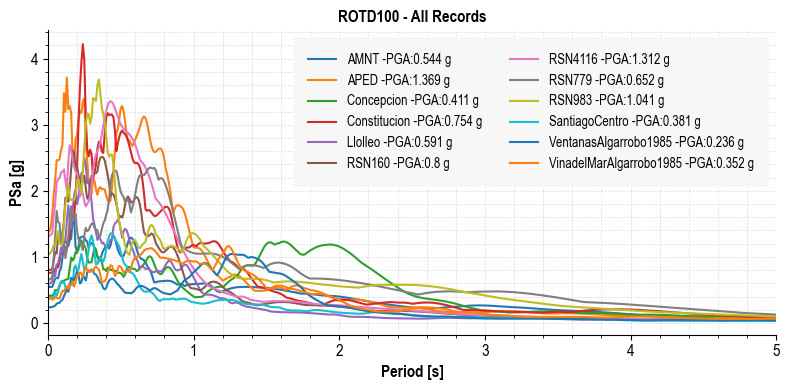

In [28]:


# Create figure with 1 row and 1 column
plt.figure(figsize=(8, 4))

# Subplot for ROTD100
plt.subplot(1, 1, 1)
for rsn, eq in earthquake.items():
    try:

        T = eq.rotd['T']
        PSa_rotd100 = eq.rotd['ROTD100']
        pga = round(PSa_rotd100[0], 3)
        plt.plot(T, PSa_rotd100, linewidth=1.5, label=f"{rsn} -PGA:{pga} g")
    except KeyError:
        print(f"Warning: {rsn} missing ROTD100 spectrum")

plt.title("ROTD100 - All Records", fontsize=12, fontweight='bold')
plt.xlabel("Period [s]", fontsize=12, fontweight='bold')
plt.ylabel("PSa [g]", fontsize=12, fontweight='bold')
plt.grid(True, which='both')
plt.xlim(left=0, right=5)
plt.tick_params(axis='both', labelsize=12)
plt.legend(fontsize=10, loc='upper right', ncol=2)
plt.tight_layout()
plt.show()


In [12]:
ppp

NameError: name 'ppp' is not defined

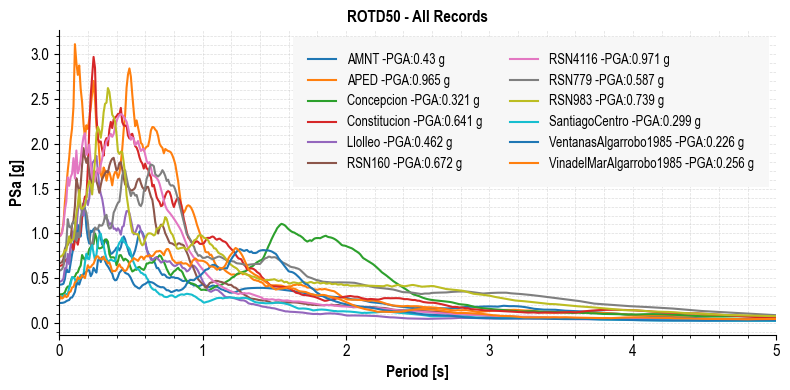

In [29]:


# Create figure with 1 row and 1 column
plt.figure(figsize=(8, 4))

# Subplot for ROTD50
plt.subplot(1, 1, 1)
for rsn, eq in earthquake.items():
    try:

        T = eq.rotd['T']
        PSa_rotd50 = eq.rotd['ROTD50']
        pga = round(PSa_rotd50[0], 3)
        plt.plot(T, PSa_rotd50, linewidth=1.5, label=f"{rsn} -PGA:{pga} g")
    except KeyError:
        print(f"Warning: {rsn} missing ROTD50 spectrum")

plt.title("ROTD50 - All Records", fontsize=12, fontweight='bold')
plt.xlabel("Period [s]", fontsize=12, fontweight='bold')
plt.ylabel("PSa [g]", fontsize=12, fontweight='bold')
plt.grid(True, which='both')
plt.xlim(left=0, right=5)
plt.tick_params(axis='both', labelsize=12)
plt.legend(fontsize=10, loc='upper right', ncol=2)
plt.tight_layout()
plt.show()


### Data Extraction

In [51]:
import pandas as pd
import numpy as np

rows = []
for rsn, eq in earthquake.items():
    name = getattr(eq, "name", str(rsn))
    dt = getattr(eq, "dt", None)
    first_signal = next(iter(eq.signals.values()))
    n_samples = len(first_signal)
    total_duration = n_samples * dt

    H1_file = eq.component_names.get('H1', None) 
    H2_file = eq.component_names.get('H2', None) 
    V_file  = eq.component_names.get('V', None)

    # Significant Duration (SD) and Arias parameters
    H1_SD = eq.arias['H1']['t_end'] - eq.arias['H1']['t_start']
    H1_IA_total = eq.arias['H1']['IA_total']
    H1_pot_dest = eq.arias['H1']['pot_dest']

    H2_SD = eq.arias['H2']['t_end'] - eq.arias['H2']['t_start']
    H2_IA_total = eq.arias['H2']['IA_total']
    H2_pot_dest = eq.arias['H2']['pot_dest']

    V_SD = eq.arias['V']['t_end'] - eq.arias['V']['t_start']
    V_IA_total = eq.arias['V']['IA_total']
    V_pot_dest = eq.arias['V']['pot_dest']

    # First dominant peak
    H1_peak1 = eq.fourier['H1']['dominant_periods'][0]
    H2_peak1 = eq.fourier['H2']['dominant_periods'][0]
    V_peak1  = eq.fourier['V']['dominant_periods'][0]

    # PGA = first value of PSa_corr
    H1_PGA = eq.newmark_spectra['H1']['PSa_corr'][0]
    H2_PGA = eq.newmark_spectra['H2']['PSa_corr'][0]
    V_PGA  = eq.newmark_spectra['V']['PSa_corr'][0]

    # PGV = first value of PSa_corr
    H1_PGV = eq.newmark_spectra['H1']['PSv_corr'][0]
    H2_PGV = eq.newmark_spectra['H2']['PSv_corr'][0]
    V_PGV  = eq.newmark_spectra['V']['PSv_corr'][0]



    # Add full spectrum
    H1_spectrum = {
        "T": eq.newmark_spectra['H1']['T'],
        "Sa": eq.newmark_spectra['H1']['PSa_corr'],
        "Sv": eq.newmark_spectra['H1']['PSv_corr'],
    }
    H2_spectrum = {
        "T": eq.newmark_spectra['H2']['T'],
        "Sa": eq.newmark_spectra['H2']['PSa_corr'],
        "Sv": eq.newmark_spectra['H2']['PSv_corr'],
    }
    V_spectrum = {
        "T": eq.newmark_spectra['V']['T'],
        "Sa": eq.newmark_spectra['V']['PSa_corr'],
        "Sv": eq.newmark_spectra['V']['PSv_corr'],
    }

    # rows.append({
    #     "record_id": str(rsn),
    #     "name": name,
    #     "dt": dt,
    #     "n_samples": n_samples,
    #     "total_duration": total_duration,
    #     "H1_file": H1_file, "H1_SD": H1_SD, "H1_IA_total": H1_IA_total, "H1_pot_dest": H1_pot_dest*100, "H1_peak1": H1_peak1 , "H1_PGA": H1_PGA , "H1_PGV": H1_PGV,    "H1_spectrum": H1_spectrum,
    #     "H2_file": H2_file, "H2_SD": H2_SD, "H2_IA_total": H2_IA_total, "H2_pot_dest": H2_pot_dest*100, "H2_peak1": H2_peak1 , "H2_PGA": H2_PGA , "H2_PGV": H2_PGV,    "H2_spectrum": H2_spectrum,
    #     "V_file":  V_file,  "V_SD": V_SD,  "V_IA_total": V_IA_total,  "V_pot_dest": V_pot_dest*100,  "V_peak1": V_peak1      , "V_PGA": V_PGA   , "V_PGV": V_PGV,      "V_spectrum": V_spectrum
    # })


    rows.append({
        "record_id": str(rsn),
        "name": name,
        "dt": dt,
        "n_samples": n_samples,
        "total_duration": total_duration,
        "H1_file": H1_file, "H1_SD": H1_SD, "H1_IA_total": H1_IA_total, "H1_pot_dest": H1_pot_dest*100, "H1_peak1": H1_peak1 , "H1_PGA": H1_PGA , "H1_PGV": H1_PGV,   
        "H2_file": H2_file, "H2_SD": H2_SD, "H2_IA_total": H2_IA_total, "H2_pot_dest": H2_pot_dest*100, "H2_peak1": H2_peak1 , "H2_PGA": H2_PGA , "H2_PGV": H2_PGV,  
        "V_file":  V_file,  "V_SD": V_SD,  "V_IA_total": V_IA_total,  "V_pot_dest": V_pot_dest*100,  "V_peak1": V_peak1      , "V_PGA": V_PGA   , "V_PGV": V_PGV,     
    })


df_records = pd.DataFrame(rows).sort_values("record_id").reset_index(drop=True)

print("✅ Registros encontrados:", len(df_records))
print(df_records.head(3))

df_records.to_pickle("df_records_full.pkl")
df_records.to_csv("df_records_full.csv", index=False, encoding="utf-8", float_format="%.6f")


✅ Registros encontrados: 12
    record_id        name     dt  n_samples  total_duration  \
0        AMNT        AMNT  0.010       5001           50.01   
1        APED        APED  0.010      17502          175.02   
2  Concepcion  Concepcion  0.005      28338          141.69   

                     H1_file   H1_SD  H1_IA_total  H1_pot_dest  H1_peak1  ...  \
0  AMNT_201604162359_N_100_N  16.270     2.287529     8.331131  0.543587  ...   
1  APED_201604162359_N_100_N  29.970    18.972749    57.533906  0.488883  ...   
2   Concepcion_Maule2010_Y_E  88.255     5.950180    21.695519  1.540109  ...   

   H2_peak1    H2_PGA H2_PGV                     V_file    V_SD  V_IA_total  \
0  2.632105  0.401839    0.0  AMNT_201604162359_Z_100_Z  22.390    0.405191   
1  0.643456  1.348642    0.0  APED_201604162359_Z_100_Z  28.530    6.285456   
2  1.557033  0.410728    0.0   Concepcion_Maule2010_Z_Z  66.095    7.984885   

   V_pot_dest   V_peak1     V_PGA V_PGV  
0    0.871147  2.632105  0.169396  

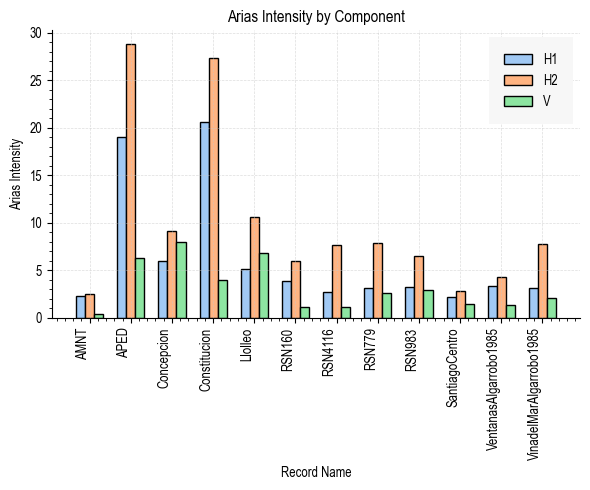


Arias Intensity - H1:
count    12.000000
mean      6.226200
std       6.441773
min       2.217975
25%       3.006380
50%       3.294493
75%       5.366425
max      20.623746
Name: H1_IA_total, dtype: float64

Arias Intensity - H2:
count    12.000000
mean     10.111430
std       8.726270
min       2.499307
25%       5.588989
50%       7.704227
75%       9.519594
max      28.805484
Name: H2_IA_total, dtype: float64

Arias Intensity - V:
count    12.000000
mean      3.166500
std       2.533258
min       0.405191
25%       1.290619
50%       2.314459
75%       4.555155
max       7.984885
Name: V_IA_total, dtype: float64


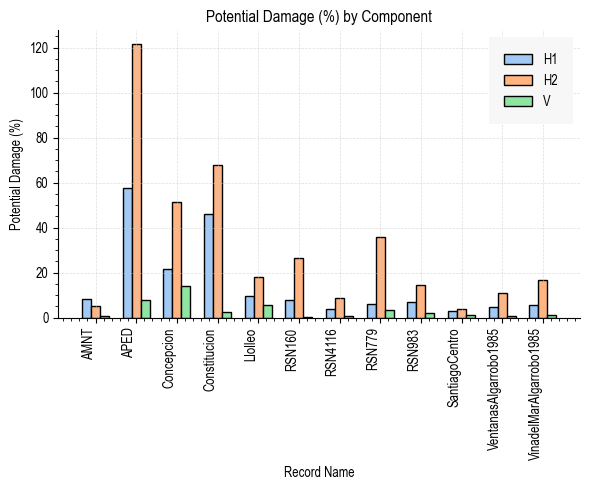


Potential Damage (%) - H1:
count    12.000000
mean     15.163942
std      17.951361
min       2.915468
25%       5.471531
50%       7.606933
75%      12.681185
max      57.533906
Name: H1_pot_dest, dtype: float64

Potential Damage (%) - H2:
count     12.000000
mean      31.801647
std       34.300434
min        3.746447
25%       10.482141
50%       17.456658
75%       39.915478
max      121.540695
Name: H2_pot_dest, dtype: float64

Potential Damage (%) - V:
count    12.000000
mean      3.413557
std       3.984242
min       0.405823
25%       0.951344
50%       1.683964
75%       4.005772
max      13.870735
Name: V_pot_dest, dtype: float64


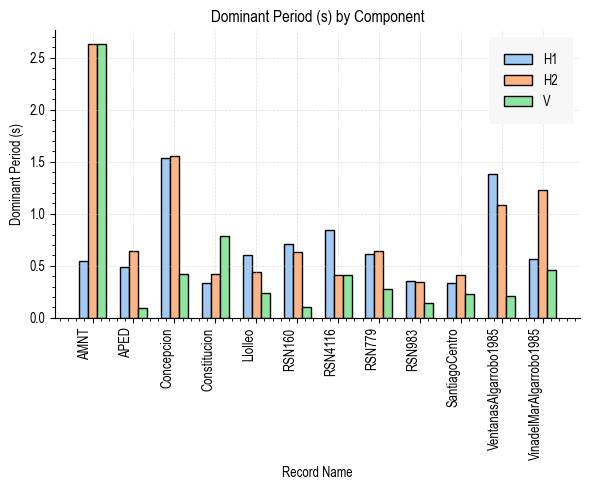


Dominant Period (s) - H1:
count    12.000000
mean      0.692597
std       0.391860
min       0.333333
25%       0.453964
50%       0.586110
75%       0.745268
max       1.540109
Name: H1_peak1, dtype: float64

Dominant Period (s) - H2:
count    12.000000
mean      0.869953
std       0.674144
min       0.345000
25%       0.420017
50%       0.635702
75%       1.122245
max       2.632105
Name: H2_peak1, dtype: float64

Dominant Period (s) - V:
count    12.000000
mean      0.500217
std       0.698469
min       0.090077
25%       0.191359
50%       0.257212
75%       0.430250
max       2.632105
Name: V_peak1, dtype: float64


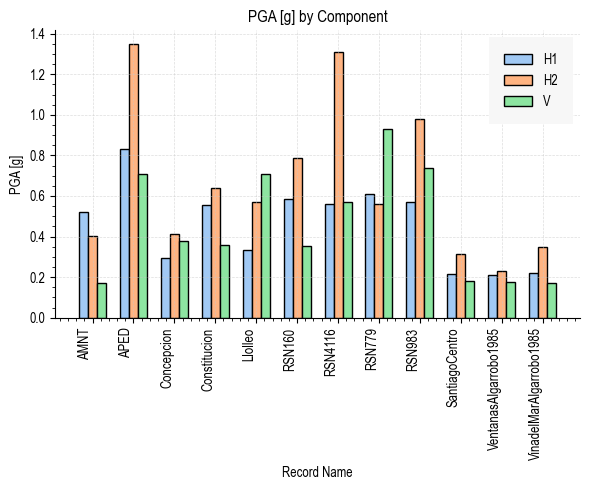


PGA [g] - H1:
count    12.000000
mean      0.458835
std       0.198951
min       0.210402
25%       0.273858
50%       0.537751
75%       0.573758
max       0.834024
Name: H1_PGA, dtype: float64

PGA [g] - H2:
count    12.000000
mean      0.658238
std       0.377140
min       0.229995
25%       0.388504
50%       0.564713
75%       0.833944
max       1.348642
Name: H2_PGA, dtype: float64

PGA [g] - V:
count    12.000000
mean      0.453972
std       0.267655
min       0.169396
25%       0.180544
50%       0.369781
75%       0.707979
max       0.928770
Name: V_PGA, dtype: float64


In [71]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Colores pastel
color_h1 = "#a1c9f4"  # pastel azul
color_h2 = "#ffb482"  # pastel naranja
color_v  = "#8de5a1"  # pastel verde

# Parámetros y títulos
params = [
    ("IA_total", ["H1_IA_total", "H2_IA_total", "V_IA_total"], "Arias Intensity"),
    ("pot_dest", ["H1_pot_dest", "H2_pot_dest", "V_pot_dest"], "Potential Damage (%)"),
    ("peak",     ["H1_peak1",    "H2_peak1",    "V_peak1"],    "Dominant Period (s)"),
    ("PGA",      ["H1_PGA",      "H2_PGA",      "V_PGA"],      "PGA [g]"),
]

component_colors = [color_h1, color_h2, color_v]
component_labels = ["H1", "H2", "V"]

svg_path = r'C:\Users\ppala\OneDrive\01. Brain\10. Ph.D U ANDES\07. Publicaciones\01. AmplificacionMuros\02. Modelos Shell\04. Model10stories\SelectedSeismic'
os.makedirs(svg_path, exist_ok=True)

# ---------- Barras agrupadas para cada parámetro ----------
for param_name, cols, title in params:
    x = np.arange(len(df_records["name"]))
    bar_width = 0.22

    plt.figure(figsize=(6, 5))
    for i, col in enumerate(cols):
        plt.bar(x + i*bar_width - bar_width, df_records[col], width=bar_width,
                label=component_labels[i], color=component_colors[i], edgecolor="black")
    plt.xticks(x, df_records["name"], rotation=90, ha="right")
    plt.xlabel("Record Name")
    plt.ylabel(title)
    plt.title(f"{title} by Component")
    plt.legend()
    plt.tight_layout()

    # --- Guardar figuras ---
    plt.savefig(os.path.join(svg_path, f'{param_name}_by_component.pdf'), format='pdf', bbox_inches='tight')
    plt.savefig(os.path.join(svg_path, f'{param_name}_by_component.svg'), format='svg', bbox_inches='tight')
    plt.show()
    plt.close()

    # Estadísticas
    for label, col in zip(component_labels, cols):
        print(f"\n{title} - {label}:")
        print(df_records[col].describe())

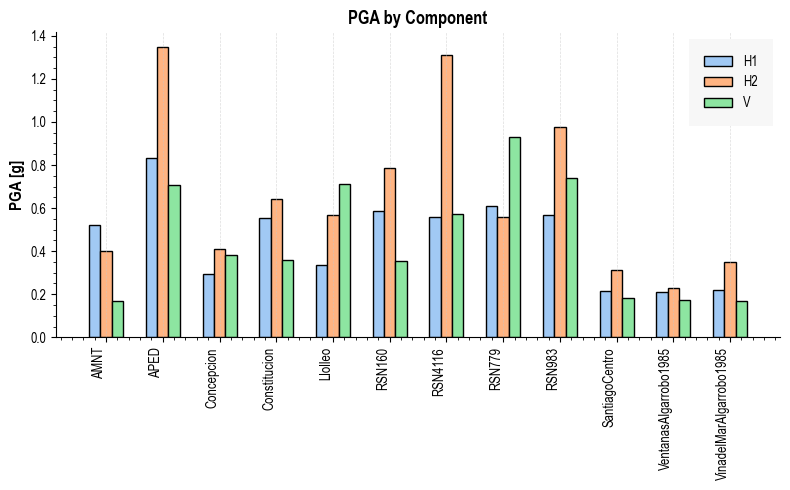

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# Posiciones en X
x = np.arange(len(df_records))
bar_width = 0.20

# Colores pastel suaves
color_h1 = "#a1c9f4"  # pastel azul
color_h2 = "#ffb482"  # pastel naranja
color_v  = "#8de5a1"  # pastel verde

# Figura con subplots
fig, ax1 = plt.subplots(figsize=(8, 5))

# ----------------------
# Subplot 1: PGA
# ----------------------
ax1.bar(x - bar_width, df_records["H1_PGA"], width=bar_width, label="H1", color=color_h1, edgecolor="black")
ax1.bar(x,             df_records["H2_PGA"], width=bar_width, label="H2", color=color_h2, edgecolor="black")
ax1.bar(x + bar_width, df_records["V_PGA"],  width=bar_width, label="V",  color=color_v,  edgecolor="black")

ax1.set_title("PGA by Component", fontweight="bold", fontsize=13)
ax1.set_ylabel("PGA [g]", fontweight="bold", fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(df_records["name"], rotation=90, ha="right")
ax1.grid(axis="y")
ax1.legend()

# --- Guardar figuras ---
plt.savefig(os.path.join(svg_path, 'PGA_peak.pdf'), format='pdf', bbox_inches='tight')
plt.savefig(os.path.join(svg_path, 'PGA_peak.svg'), format='svg', bbox_inches='tight')

plt.tight_layout()
plt.show()

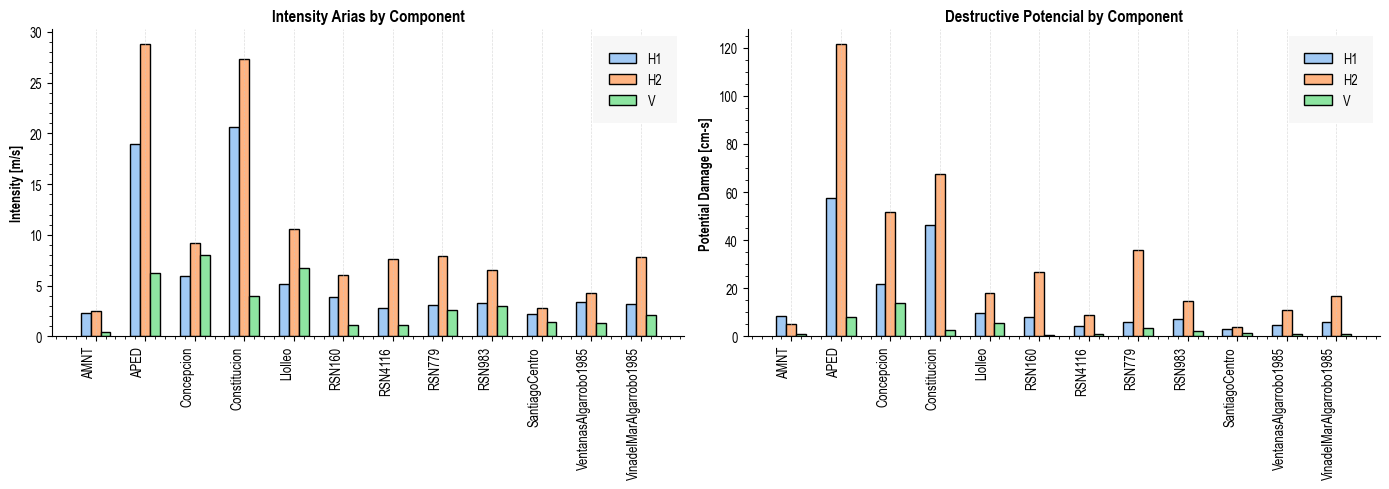

In [74]:
import numpy as np
import matplotlib.pyplot as plt

# Posiciones en X
x = np.arange(len(df_records))
bar_width = 0.20

# Colores pastel suaves
color_h1 = "#a1c9f4"  # pastel azul
color_h2 = "#ffb482"  # pastel naranja
color_v  = "#8de5a1"  # pastel verde

# Figura con subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# ----------------------
# Subplot 1: PGA
# ----------------------
ax1.bar(x - bar_width, df_records["H1_IA_total"], width=bar_width, label="H1", color=color_h1, edgecolor="black")
ax1.bar(x,             df_records["H2_IA_total"], width=bar_width, label="H2", color=color_h2, edgecolor="black")
ax1.bar(x + bar_width, df_records["V_IA_total"],  width=bar_width, label="V",  color=color_v,  edgecolor="black")

ax1.set_title("Intensity Arias by Component", fontweight="bold")
ax1.set_ylabel("Intensity [m/s]", fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(df_records["name"], rotation=90, ha="right")
ax1.grid(axis="y")
ax1.legend()

# ----------------------
# Subplot 2: Dominant Period
# ----------------------
ax2.bar(x - bar_width, df_records["H1_pot_dest"], width=bar_width, label="H1", color=color_h1, edgecolor="black")
ax2.bar(x,             df_records["H2_pot_dest"], width=bar_width, label="H2", color=color_h2, edgecolor="black")
ax2.bar(x + bar_width, df_records["V_pot_dest"],  width=bar_width, label="V",  color=color_v,  edgecolor="black")

ax2.set_title("Destructive Potencial by Component", fontweight="bold")
ax2.set_ylabel("Potential Damage [cm-s]", fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(df_records["name"], rotation=90, ha="right")
ax2.grid(axis="y")
ax2.legend()


# --- Guardar figuras ---
plt.savefig(os.path.join(svg_path, 'IA_potdest.pdf'), format='pdf', bbox_inches='tight')
plt.savefig(os.path.join(svg_path, 'IA_potdest.svg'), format='svg', bbox_inches='tight')

plt.tight_layout()
plt.show()


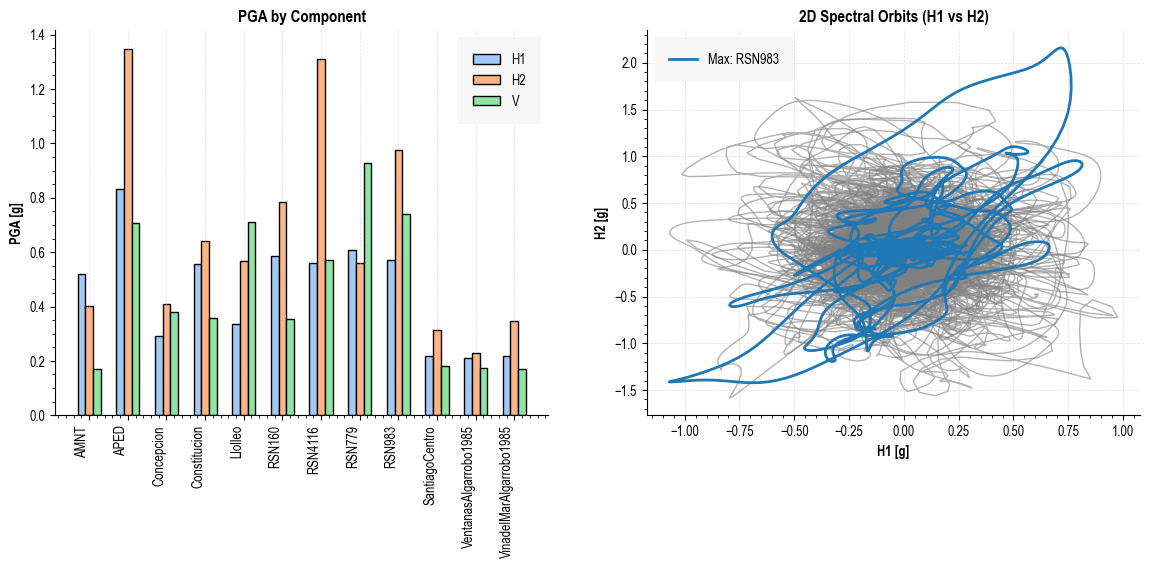

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Posiciones en X
x = np.arange(len(df_records))
bar_width = 0.20

# Colores pastel suaves
color_h1 = "#a1c9f4"  # pastel azul
color_h2 = "#ffb482"  # pastel naranja
color_v  = "#8de5a1"  # pastel verde

# Figura con subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ----------------------
# Subplot 1: PGA
# ----------------------
ax1.bar(x - bar_width, df_records["H1_PGA"], width=bar_width, label="H1", color=color_h1, edgecolor="black")
ax1.bar(x,             df_records["H2_PGA"], width=bar_width, label="H2", color=color_h2, edgecolor="black")
ax1.bar(x + bar_width, df_records["V_PGA"],  width=bar_width, label="V",  color=color_v,  edgecolor="black")

ax1.set_title("PGA by Component", fontweight="bold")
ax1.set_ylabel("PGA [g]", fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(df_records["name"], rotation=90, ha="right")
ax1.grid(axis="y")
ax1.legend()

# ----------------------
# Subplot 2: 2D Orbit H1 vs H2
# ----------------------

# Buscar la órbita de mayor magnitud (norma más alta)
max_r = -np.inf
max_rsn = None
orbits = {}

for rsn, eq in earthquake.items():
    try:
        a1 = np.array(eq.newmark_spectra["H1"]["a_corr"])
        a2 = np.array(eq.newmark_spectra["H2"]["a_corr"])
        n = min(len(a1), len(a2))
        a1, a2 = a1[:n], a2[:n]
        r = np.sqrt(a1**2 + a2**2)
        peak_r = np.max(r)
        orbits[rsn] = (a1, a2)
        if peak_r > max_r:
            max_r = peak_r
            max_rsn = rsn
    except KeyError:
        continue

# Primero: graficar todas las órbitas grises
for rsn, (a1, a2) in orbits.items():
    if rsn != max_rsn:
        ax2.plot(a1, a2, color='gray', alpha=0.6, linewidth=1)

# Luego: graficar la órbita máxima en azul
a1_max, a2_max = orbits[max_rsn]
ax2.plot(a1_max, a2_max, color='tab:blue', linewidth=2.0, label=f"Max: {max_rsn}")


ax2.set_title("2D Spectral Orbits (H1 vs H2)", fontweight="bold")
ax2.set_xlabel("H1 [g]", fontweight="bold")
ax2.set_ylabel("H2 [g]", fontweight="bold")
ax2.grid(True)
ax2.legend()

plt.show()


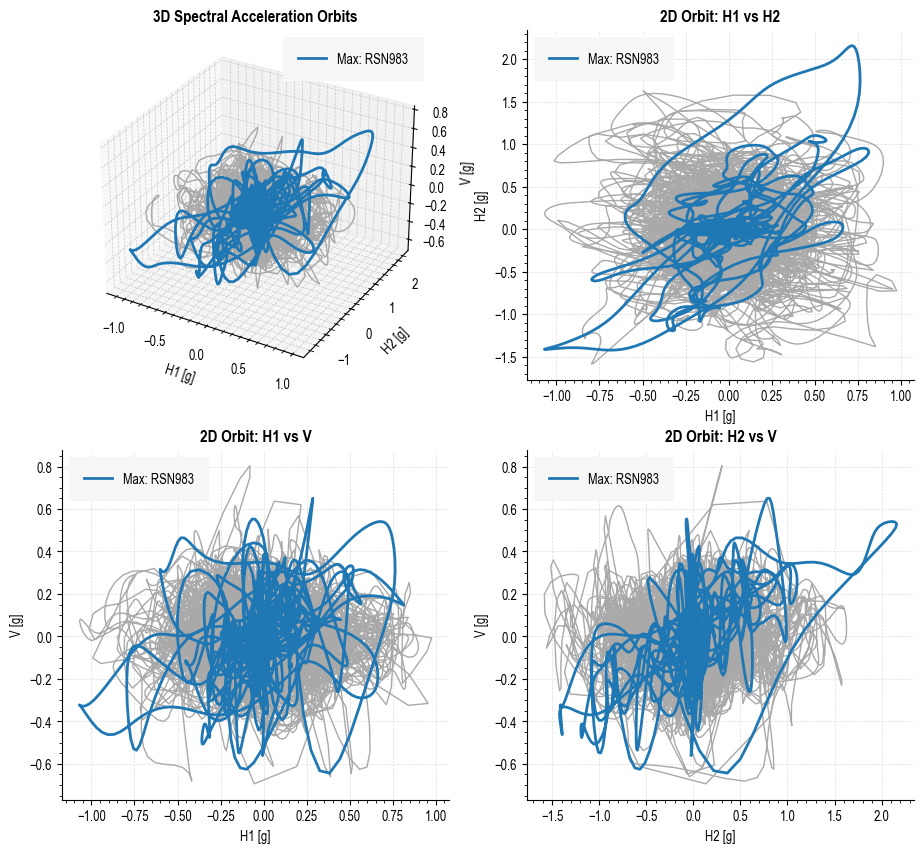

In [35]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# ========== Preprocesamiento ==========
max_r_by_record = {}
all_orbits_3d = {}

for rsn, eq in earthquake.items():
    try:
        a1 = eq.newmark_spectra["H1"]["a_corr"]
        a2 = eq.newmark_spectra["H2"]["a_corr"]
        a3 = eq.newmark_spectra["V"]["a_corr"]
    except KeyError:
        continue

    n = min(len(a1), len(a2), len(a3))
    a1 = np.array(a1[:n])
    a2 = np.array(a2[:n])
    a3 = np.array(a3[:n])

    r = np.sqrt(a1**2 + a2**2 + a3**2)
    max_r = np.max(r)
    max_r_by_record[rsn] = max_r
    all_orbits_3d[rsn] = (a1, a2, a3)

max_rsn = max(max_r_by_record, key=max_r_by_record.get)
a1_max, a2_max, a3_max = all_orbits_3d[max_rsn]

# ========== Figure con 4 subplots ==========
fig = plt.figure(figsize=(11, 10))

# Subplot 1: 3D ORBIT (H1, H2, V)
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
for rsn, (a1, a2, a3) in all_orbits_3d.items():
    if rsn == max_rsn:
        continue
    ax1.plot(a1, a2, a3, color='darkgray', linewidth=1)
ax1.plot(a1_max, a2_max, a3_max, color='tab:blue', linewidth=2.0, label=f"Max: {max_rsn}")
ax1.set_title("3D Spectral Acceleration Orbits", fontweight="bold")
ax1.set_xlabel("H1 [g]")
ax1.set_ylabel("H2 [g]")
ax1.set_zlabel("V [g]")
ax1.legend()

# Subplot 2: PLANTA (H1 vs H2)
ax2 = fig.add_subplot(2, 2, 2)
for rsn, (a1, a2, _) in all_orbits_3d.items():
    if rsn == max_rsn:
        continue
    ax2.plot(a1, a2, color='darkgray', linewidth=1)
ax2.plot(a1_max, a2_max, color='tab:blue', linewidth=2.0, label=f"Max: {max_rsn}")
ax2.set_title("2D Orbit: H1 vs H2", fontweight="bold")
ax2.set_xlabel("H1 [g]")
ax2.set_ylabel("H2 [g]")
ax2.grid(True)
ax2.legend()

# Subplot 3: VISTA LATERAL YZ (H1 vs V)
ax3 = fig.add_subplot(2, 2, 3)
for rsn, (a1, _, a3) in all_orbits_3d.items():
    if rsn == max_rsn:
        continue
    ax3.plot(a1, a3, color='darkgray', linewidth=1)
ax3.plot(a1_max, a3_max, color='tab:blue', linewidth=2.0, label=f"Max: {max_rsn}")
ax3.set_title("2D Orbit: H1 vs V", fontweight="bold")
ax3.set_xlabel("H1 [g]")
ax3.set_ylabel("V [g]")
ax3.grid(True)
ax3.legend()

# Subplot 4: VISTA LATERAL XZ (H2 vs V)
ax4 = fig.add_subplot(2, 2, 4)
for rsn, (_, a2, a3) in all_orbits_3d.items():
    if rsn == max_rsn:
        continue
    ax4.plot(a2, a3, color='darkgray', linewidth=1)
ax4.plot(a2_max, a3_max, color='tab:blue', linewidth=2.0, label=f"Max: {max_rsn}")
ax4.set_title("2D Orbit: H2 vs V", fontweight="bold")
ax4.set_xlabel("H2 [g]")
ax4.set_ylabel("V [g]")
ax4.grid(True)
ax4.legend()

# Mostrar

plt.show()


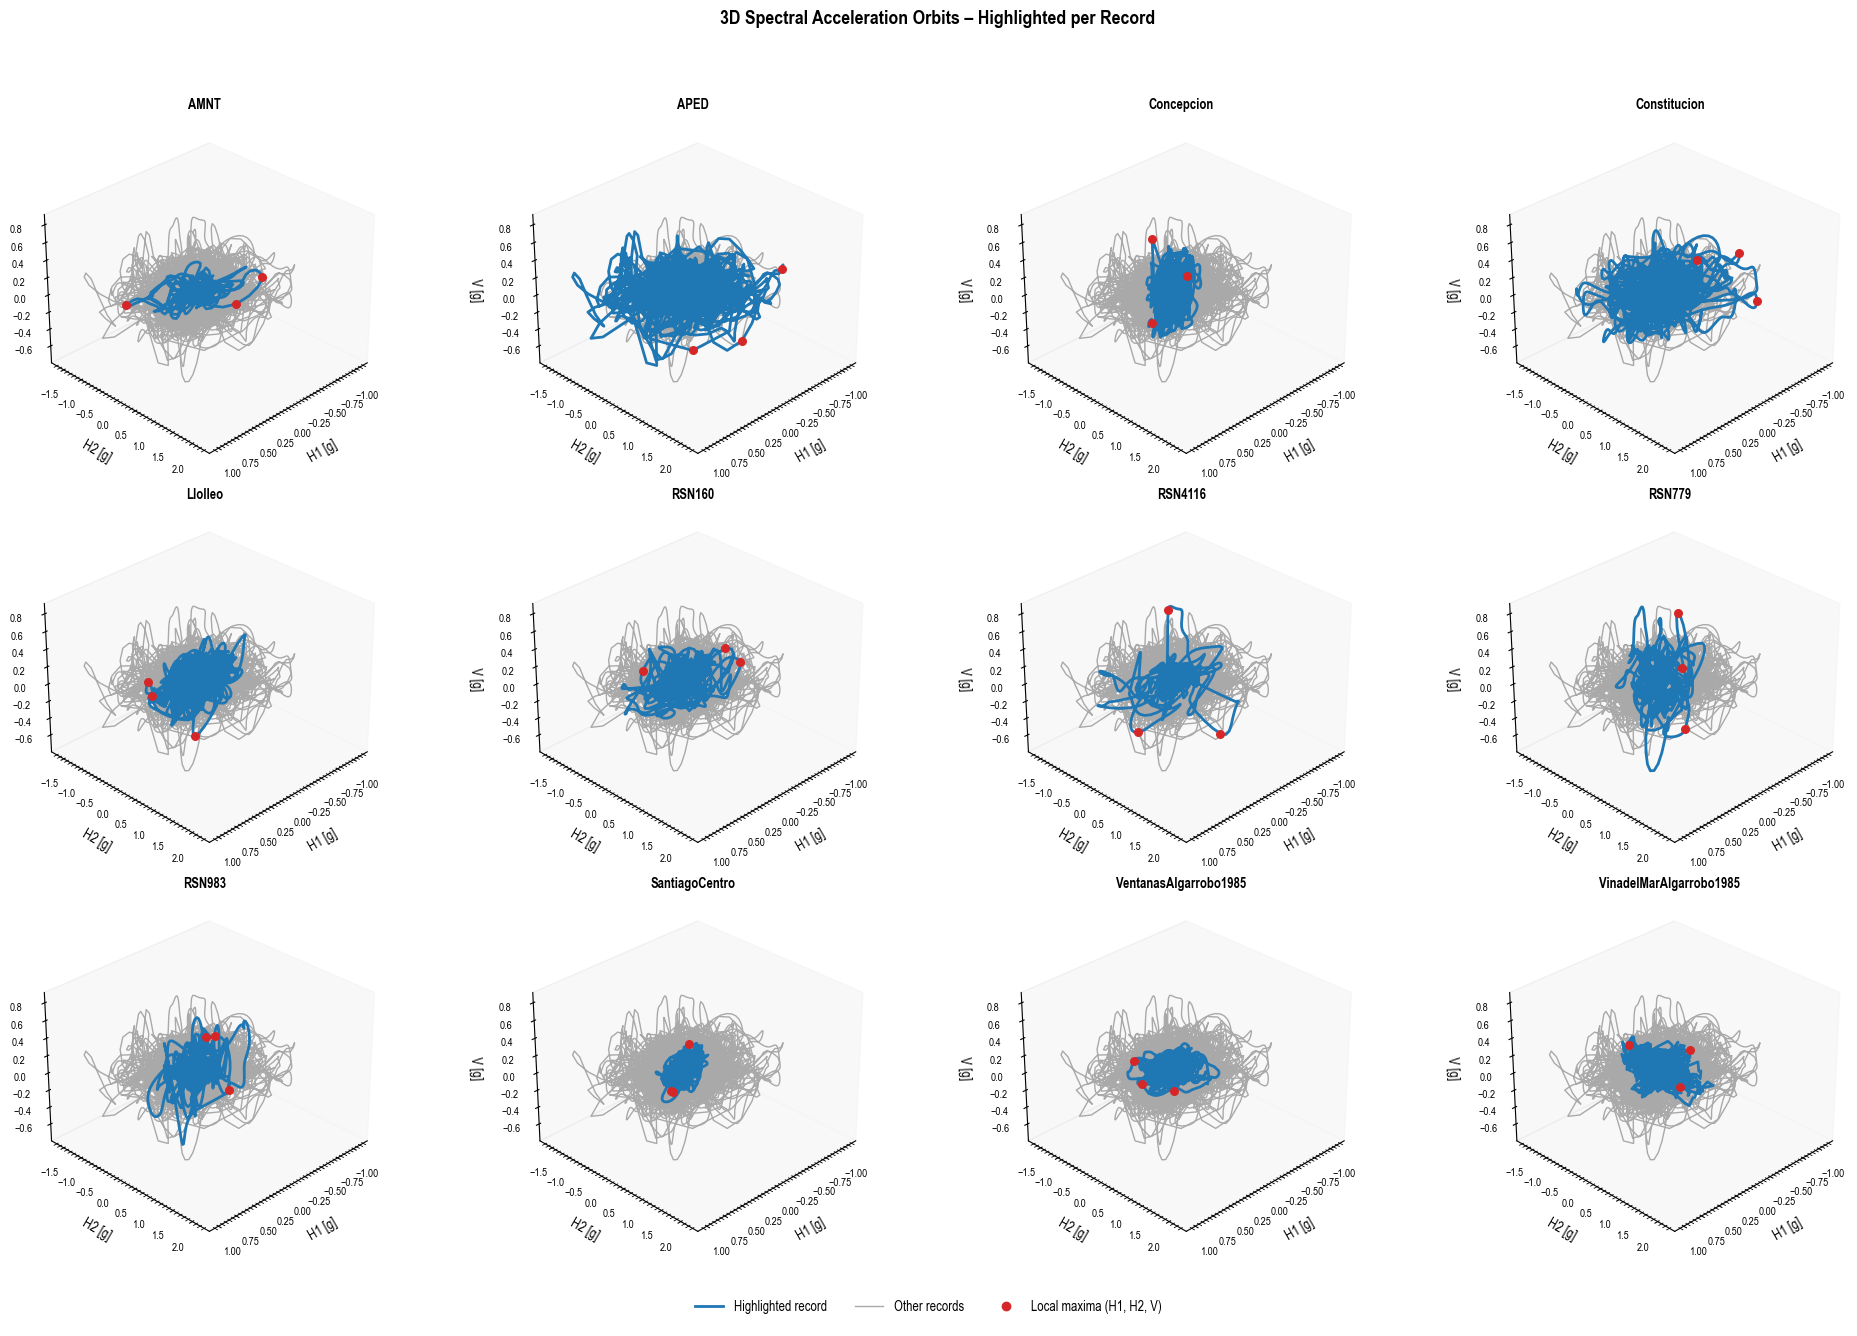

In [40]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# ========== Preprocesamiento ==========
all_orbits_3d = {}
for rsn, eq in earthquake.items():
    try:
        a1 = eq.newmark_spectra["H1"]["a_corr"]
        a2 = eq.newmark_spectra["H2"]["a_corr"]
        a3 = eq.newmark_spectra["V"]["a_corr"]
    except KeyError:
        continue

    n = min(len(a1), len(a2), len(a3))
    a1 = np.array(a1[:n])
    a2 = np.array(a2[:n])
    a3 = np.array(a3[:n])
    all_orbits_3d[rsn] = (a1, a2, a3)

# ========== Figure: 4 columnas por fila ==========
num_eq = len(all_orbits_3d)
ncols = 4
nrows = int(np.ceil(num_eq / ncols))
fig = plt.figure(figsize=(5 * ncols, 4.5 * nrows))

# ========== Subplots ==========
for idx, (highlight_rsn, (a1_main, a2_main, a3_main)) in enumerate(all_orbits_3d.items(), 1):
    ax = fig.add_subplot(nrows, ncols, idx, projection='3d')
    
    # Fondo gris claro
    ax.xaxis.pane.set_facecolor((0.95, 0.95, 0.95))
    ax.yaxis.pane.set_facecolor((0.95, 0.95, 0.95))
    ax.zaxis.pane.set_facecolor((0.95, 0.95, 0.95))

    # Sin cuadrícula
    ax.grid(False)

    # Dibujar todos los sismos en gris (excepto el destacado)
    for rsn, (a1, a2, a3) in all_orbits_3d.items():
        if rsn == highlight_rsn:
            continue
        ax.plot(a1, a2, a3, color='darkgray', linewidth=1)

    # Dibujar el sismo principal en azul
    ax.plot(a1_main, a2_main, a3_main, color='tab:blue', linewidth=2.0, label='Highlighted record')

    # === Agregar máximos como puntos rojos ===
    idx_max_H1 = np.argmax(np.abs(a1_main))
    idx_max_H2 = np.argmax(np.abs(a2_main))
    idx_max_V  = np.argmax(np.abs(a3_main))

    ax.scatter(a1_main[idx_max_H1], a2_main[idx_max_H1], a3_main[idx_max_H1],
               color='tab:red', s=30, label='Max H1' if idx == 1 else None)
    ax.scatter(a1_main[idx_max_H2], a2_main[idx_max_H2], a3_main[idx_max_H2],
               color='tab:red', s=30, label='Max H2' if idx == 1 else None)
    ax.scatter(a1_main[idx_max_V], a2_main[idx_max_V], a3_main[idx_max_V],
               color='tab:red', s=30, label='Max V'  if idx == 1 else None)

    # Estética
    ax.set_title(highlight_rsn, fontsize=10, fontweight='bold')
    ax.set_xlabel("H1 [g]")
    ax.set_ylabel("H2 [g]")
    ax.set_zlabel("V [g]")
    ax.tick_params(labelsize=8)
    ax.view_init(elev=30, azim=45)

# ========== Leyenda global ==========
handles = [
    plt.Line2D([0], [0], color='tab:blue', lw=2, label='Highlighted record'),
    plt.Line2D([0], [0], color='darkgray', lw=1, label='Other records'),
    plt.Line2D([0], [0], marker='o', color='tab:red', linestyle='None', markersize=6, label='Local maxima (H1, H2, V)')
]

fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=10, frameon=False)

# ========== Ajustes finales ==========
plt.suptitle("3D Spectral Acceleration Orbits – Highlighted per Record", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # deja espacio abajo para leyenda global
plt.show()
